El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales donde se emplean filtros de 3x3 y 5x5 en cada capa y se concatenan las salida para la entrada a la capa siguiente

Importación de librerías

In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose, Concatenate, Activation # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler  # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19

2025-11-14 13:23:04.081392: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-14 13:23:04.188658: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-14 13:23:04.240957: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-14 13:23:04.254577: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-14 13:23:04.325789: I tensorflow/core/platform/cpu_feature_guar

Funciones

In [2]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [3]:
# Directorio con imagenes en tamaño original y  tamaño reducido
d_reducida = '/home/jhon/bandas/banda13/ene_oct_10m_reducida'

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas
# Normalización
all_pixels = np.concatenate([img.flatten() for img in images])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images = [(img - global_min) / (global_max - global_min + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

Procesando 7250 imágenes
Forma de X: (7249, 480, 480, 1)
Forma de y: (7249, 480, 480, 1)


Creación de un modelo simple de redes neuronales convolucionales

In [5]:
# Semilla
semilla = 42
tf.random.set_seed(semilla)

# Entrada (1 canal para imágenes GOES) - 480x480x1
inputs = Input(shape=X.shape[1:])  # (480, 480, 1)

print(f"Shape de entrada: {X.shape[1:]}")

# === ADAPTADOR PARA VGG19 ===
# Convertir de 1 canal a 3 canales replicando la información
x_adapter = Conv2D(3, (1, 1), padding='same', activation='linear', name='channel_adapter')(inputs)

# === VGG19 COMO EXTRACTOR DE CARACTERÍSTICAS ===
# Cargar VGG19 pre-entrenado (sin capas fully-connected)
vgg_base = VGG19(weights='imagenet', 
                 include_top=False, 
                 input_shape=(X.shape[1], X.shape[2], 3))

# Congelar VGG19 inicialmente
vgg_base.trainable = False

# Extraer características de VGG19
vgg_features = vgg_base(x_adapter, training=False)

print(f"Salida VGG19: {vgg_features.shape}")

# === RECONSTRUCCIÓN DE RESOLUCIÓN ORIGINAL ===
# VGG19 reduce 480x480 -> 15x15 (5 maxpooling layers)
# Necesitamos reconstruir de 15x15 a 480x480

# Opción A: Upsampling progresivo con convoluciones transpuestas
x = Conv2D(512, (3, 3), padding='same', activation='relu')(vgg_features)  # 15x15x512

# Bloque de upsampling 1: 15x15 -> 30x30
x = Conv2DTranspose(256, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)  # 30x30x256
x = Conv2D(256, (3, 3), padding='same', activation='relu')(x)

# Bloque de upsampling 2: 30x30 -> 60x60
x = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)  # 60x60x128
x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)

# Bloque de upsampling 3: 60x60 -> 120x120
x = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)  # 120x120x64
x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)

# Bloque de upsampling 4: 120x120 -> 240x240
x = Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)  # 240x240x32
x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)

# Bloque de upsampling 5: 240x240 -> 480x480
x = Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)  # 480x480x32
bridge = Conv2D(32, (3, 3), padding='same', activation='relu', name='dimensionality_bridge')(x)

print(f"Shape después de upsampling: {bridge.shape}")

# === VERIFICACIÓN DE DIMENSIONES ===
assert bridge.shape[1] == X.shape[1] and bridge.shape[2] == X.shape[2], \
    f"Error: bridge {bridge.shape[1:]} no coincide con entrada {X.shape[1:]}"

# === TU ARQUITECTURA RESIDUAL ORIGINAL (MODIFICADA) ===

# === Bloque 1 ===
x1_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(bridge)
x1_5 = Conv2D(16, (5, 5), padding='same', activation='relu')(bridge)
res1 = Concatenate()([x1_3, x1_5])  # 32 canales

# === Bloque 2 ===
x2_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res1)
x2_5 = Conv2D(16, (5, 5), padding='same', activation='relu')(res1)

# 🔗 Conexión residual (concatenación)
res2 = Concatenate()([x2_3, x2_5])  # 32 canales
res2 = res2 + res1
res2 = Activation('relu')(res2)

# === Bloque 3 ===
x3_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res2)
x3_5 = Conv2D(16, (5, 5), padding='same', activation='relu')(res2)

# 🔗 Conexión residual (concatenación)
res3 = Concatenate()([x3_3, x3_5])  # 32 canales
res3 = res3 + res2
res3 = Activation('relu')(res3)

# === Bloque 4 (reducción de canales) ===
x4_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res3)
x4_5 = Conv2D(16, (5, 5), padding='same', activation='relu')(res3)

# 🔗 Conexión final (concatenación con la salida inicial)
res_final = Concatenate()([x4_3, x4_5])  # 32 canales
res_final = res_final + res3
res_final = Activation('relu')(res_final)

# === CAPAS FINALES PARA REGRESIÓN ===
# Capa de refinamiento antes de la salida
x_final = Conv2D(16, (3, 3), padding='same', activation='relu')(res_final)
x_final = Conv2D(8, (3, 3), padding='same', activation='relu')(x_final)

# === Salida === Conv 1x1
outputs = Conv2D(1, (1, 1), padding='same', activation='linear')(x_final)

print(f"Shape de salida: {outputs.shape}")

# =====================================================
# PARÁMETROS DEL DECAY COSENOIDAL
# =====================================================
initial_lr = 1e-4       # Tasa de aprendizaje inicial (más baja por VGG)
min_lr = 1e-6           # Tasa mínima al final del entrenamiento
epochs_total = 50       # Debe coincidir con el número de épocas del entrenamiento

# =====================================================
# FUNCIÓN COSINE DECAY (schedule)
# =====================================================
def cosine_decay_schedule(epoch, lr):
    """
    Calcula el decaimiento cosenoidal:
    lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + cos(pi * epoch / total_epochs))
    """
    cosine_decay = 0.5 * (1 + np.cos(np.pi * epoch / epochs_total))
    new_lr = min_lr + (initial_lr - min_lr) * cosine_decay
    return new_lr

# Crear callback de tasa de aprendizaje
lr_scheduler = LearningRateScheduler(cosine_decay_schedule, verbose=1)

# =====================================================
# DEFINICIÓN DEL MODELO
# =====================================================
model_vgg = Model(inputs=inputs, outputs=outputs)

optimizer = Adam(learning_rate=initial_lr)
model_vgg.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

print("Resumen del modelo con VGG19:")
model_vgg.summary()

# =====================================================
# CALLBACKS
# =====================================================
checkpoint = ModelCheckpoint(
    filepath="modelo_vgg19_goes_best.h5",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# =====================================================
# DIVISIÓN CRONOLÓGICA DE DATOS
# =====================================================
porc_validacion = 0.2
split_index = int(len(X) * (1 - porc_validacion))

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

print(f"Tamaño entrenamiento: {len(X_train)} muestras")
print(f"Tamaño validación: {len(X_val)} muestras")
print(f"Shape X_train: {X_train.shape}, Shape y_train: {y_train.shape}")

# =====================================================
# ESTRATEGIA DE ENTRENAMIENTO EN DOS FASES
# =====================================================

# FASE 1: Entrenar con VGG19 congelado
print("=== FASE 1: Entrenamiento con VGG19 congelado ===")
history_phase1 = model_vgg.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=4,
    callbacks=[early_stop, checkpoint, lr_scheduler],
    verbose=1
)

# FASE 2: Fine-tuning (OPCIONAL - solo si es necesario)
print("=== FASE 2: Fine-tuning (Opcional) ===")

# Descongelar los últimos bloques de VGG19 para fine-tuning
vgg_base.trainable = True

# Congelar primeras capas, descongelar últimas
for layer in vgg_base.layers[:15]:
    layer.trainable = False

# Recompilar con learning rate más bajo para fine-tuning
fine_tune_lr = 1e-5
optimizer_ft = Adam(learning_rate=fine_tune_lr)
model_vgg.compile(
    optimizer=optimizer_ft,
    loss='mse',
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

history_phase2 = model_vgg.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=4,
    callbacks=[early_stop],
    verbose=1
)

print("¡Entrenamiento completado!")

Shape de entrada: (480, 480, 1)
Salida VGG19: (None, 15, 15, 512)
Shape después de upsampling: (None, 480, 480, 32)
Shape de salida: (None, 480, 480, 1)
Resumen del modelo con VGG19:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 480, 480,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ channel_adapter     │ (None, 480, 480,  │          6 │ input_layer_2[0]… │
│ (Conv2D)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg19 (Functional)  │ (None, 15, 15,    │ 20,024,384 │ channel_adapter[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 15, 15,    │  2,359,808 │ vgg19[0][0]       │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 30, 30,    │  1,179,904 │ conv2d_11[0][0]   │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 30, 30,    │    590,080 │ conv2d_transpose… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 60, 60,    │    295,040 │ conv2d_12[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 60, 60,    │    147,584 │ conv2d_transpose… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 120, 120,  │     73,792 │ conv2d_13[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 120, 120,  │     36,928 │ conv2d_transpose… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 240, 240,  │     18,464 │ conv2d_14[0][0]   │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 240, 240,  │      9,248 │ conv2d_transpose… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 480, 480,  │      9,248 │ conv2d_15[0][0]   │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dimensionality_bri… │ (None, 480, 480,  │      9,248 │ conv2d_transpose… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 480, 480,  │      4,624 │ dimensionality_b… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 480, 480,  │     12,816 │ dimensionality_b… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 480, 480,  │          0 │ conv2d_16[0][0],

 Total params: 24,829,287 (94.72 MB)

 Trainable params: 4,804,903 (18.33 MB)

...

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 182s 126ms/step - loss: 0.0074 - mean_absolute_percentage_error: 21.1755 - root_mean_squared_error: 0.0861 - val_loss: 0.0100 - val_mean_absolute_percentage_error: 26.6118 - val_root_mean_squared_error: 0.1002 - learning_rate: 9.6524e-05

Epoch 8: LearningRateScheduler setting learning rate to 9.528893909706797e-05.
Epoch 8/30
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.0072 - mean_absolute_percentage_error: 20.7110 - root_mean_squared_error: 0.0851
Epoch 8: val_loss did not improve from 0.01004
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 182s 126ms/step - loss: 0.0072 - mean_absolute_percentage_error: 20.7434 - root_mean_squared_error: 0.0849 - val_loss: 0.0101 - val_mean_absolute_percentage_error: 26.8054 - val_root_mean_squared_error: 0.1005 - learning_rate: 9.5289e-05

Epoch 9: LearningRateScheduler setting learning rate to 9.387718066217124e-05.
Epoch 9/30
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.0070 - mean_absolute_percentage_error: 20.

2025-11-10 19:21:45.099208: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_2', 76 bytes spill stores, 76 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_10', 200 bytes spill stores, 200 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_7', 8 bytes spill stores, 8 bytes spill loads



1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0069 - mean_absolute_percentage_error: 19.9906 - root_mean_squared_error: 0.0830

2025-11-10 19:24:46.587804: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_compare_reduce_fusion_2', 332 bytes spill stores, 348 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_10', 200 bytes spill stores, 200 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_7', 8 bytes spill stores, 8 bytes spill loads



1450/1450 ━━━━━━━━━━━━━━━━━━━━ 208s 137ms/step - loss: 0.0066 - mean_absolute_percentage_error: 19.6179 - root_mean_squared_error: 0.0815 - val_loss: 0.0086 - val_mean_absolute_percentage_error: 23.4325 - val_root_mean_squared_error: 0.0926
Epoch 2/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 190s 131ms/step - loss: 0.0062 - mean_absolute_percentage_error: 18.5609 - root_mean_squared_error: 0.0785 - val_loss: 0.0083 - val_mean_absolute_percentage_error: 22.7545 - val_root_mean_squared_error: 0.0911
Epoch 3/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 190s 131ms/step - loss: 0.0059 - mean_absolute_percentage_error: 17.9478 - root_mean_squared_error: 0.0769 - val_loss: 0.0082 - val_mean_absolute_percentage_error: 22.3811 - val_root_mean_squared_error: 0.0904
Epoch 4/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 191s 131ms/step - loss: 0.0057 - mean_absolute_percentage_error: 17.4869 - root_mean_squared_error: 0.0757 - val_loss: 0.0081 - val_mean_absolute_percentage_error: 22.1602 - val_root_mean_squared_error: 0.0900
Epo

In [6]:
# === ADAPTADOR PARA VGG19 ===
# Convertir de 1 canal a 3 canales replicando la información
# x_adapter = Conv2D(3, (1, 1), padding='same', activation='linear', name='channel_adapter')(inputs)

# === VGG19 COMO EXTRACTOR DE CARACTERÍSTICAS ===
# Cargar VGG19 pre-entrenado (sin capas fully-connected)
vgg_base = VGG19(weights='imagenet', 
                 include_top=False, 
                 input_shape=(480,480, 3))

# Congelar VGG19 inicialmente
vgg_base.trainable = False

# Extraer características de VGG19
#vgg_features = vgg_base(x_adapter, training=False)

#print(f"Salida VGG19: {vgg_features.shape}")

2025-11-14 13:26:14.305685: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46755 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:52:00.0, compute capability: 8.6


In [7]:
vgg_pesos = vgg_base.get_weights()

In [11]:
vgg_pesos[2].shape

(3, 3, 64, 64)

In [ ]:
from tensorflow.keras import layers

# Create the Conv2D layer
replicate_layer = layers.Conv2D(
    filters=3,              # output channels
    kernel_size=1,          # 1x1 convolution
    use_bias=False,         # no bias needed
    trainable=False,        # freeze the layer
    name="replicate_layer"
)

# Build the layer by providing an input shape (batch, H, W, 1)
replicate_layer.build(input_shape=(None, None, None, 1))

# Set all weights to 1 so each output channel = input_channel * 1
weights = tf.ones((1, 1, 1, 3))  # shape: (kernel_h, kernel_w, in_channels, out_channels)
replicate_layer.set_weights([weights])

Valores de las metricas

RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 0.0057, RMSE final: 0.0756, MAPE final: 17.5224
Validación    - Loss final: 0.0114, RMSE final: 0.1067, MAPE final: 24.9763


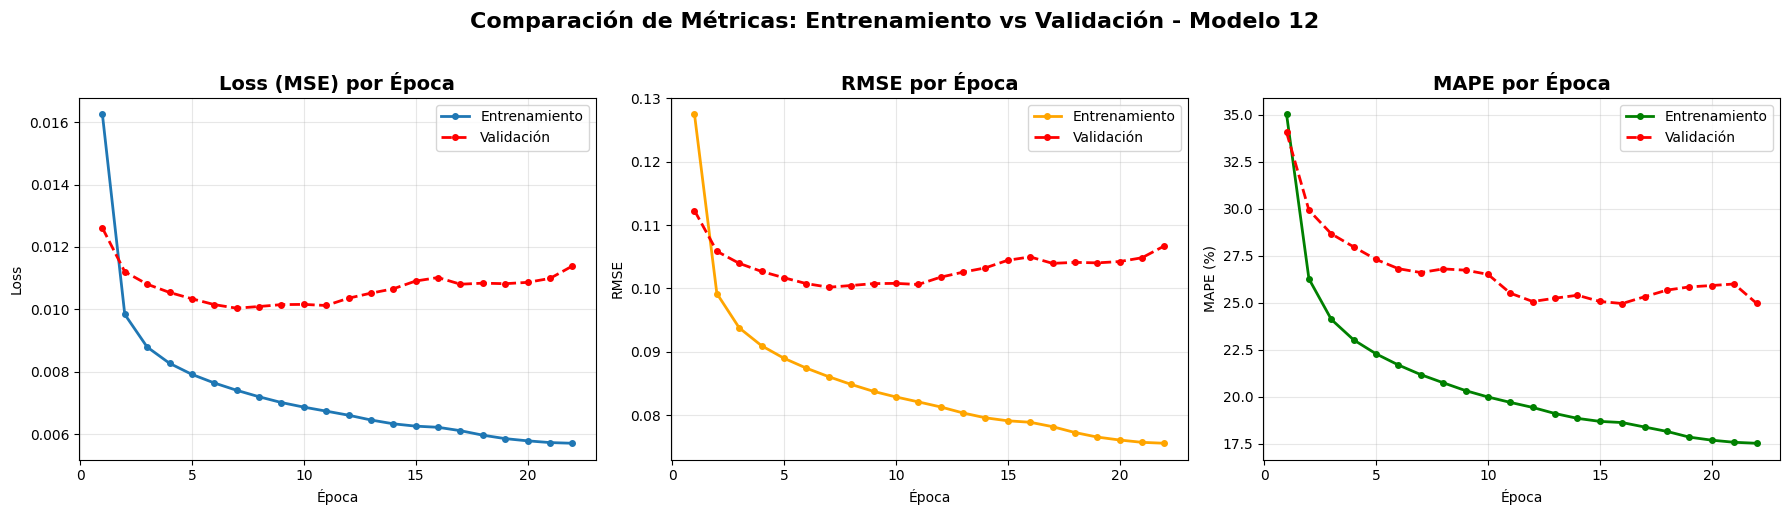

In [6]:
import matplotlib.pyplot as plt

# Extraer métricas del historial (entrenamiento y validación)
loss = history_phase1.history['loss']
val_loss = history_phase1.history['val_loss']

rmse = history_phase1.history['root_mean_squared_error']
val_rmse = history_phase1.history['val_root_mean_squared_error']
mape = history_phase1.history['mean_absolute_percentage_error']
val_mape = history_phase1.history['val_mean_absolute_percentage_error']

epochs = range(1, len(loss) + 1)

# Mostrar resumen final
print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss final: {val_loss[-1]:.4f}, RMSE final: {val_rmse[-1]:.4f}, MAPE final: {val_mape[-1]:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_rmse, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_mape, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación - Modelo 12',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model_vgg.evaluate(X_train, y_train, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

182/182 ━━━━━━━━━━━━━━━━━━━━ 72s 291ms/step - loss: 0.0054 - mean_absolute_percentage_error: 16.5202 - root_mean_squared_error: 0.0734
Pérdida (MSE): 0.0054
RMSE: 0.0734
MAPE: 16.5202


In [8]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model_vgg.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 19s 408ms/step - loss: 0.0081 - mean_absolute_percentage_error: 22.0016 - root_mean_squared_error: 0.0898
Pérdida (MSE): 0.0081
RMSE: 0.0898
MAPE: 22.0016


Visualización de imagenes

182/182 ━━━━━━━━━━━━━━━━━━━━ 50s 270ms/step


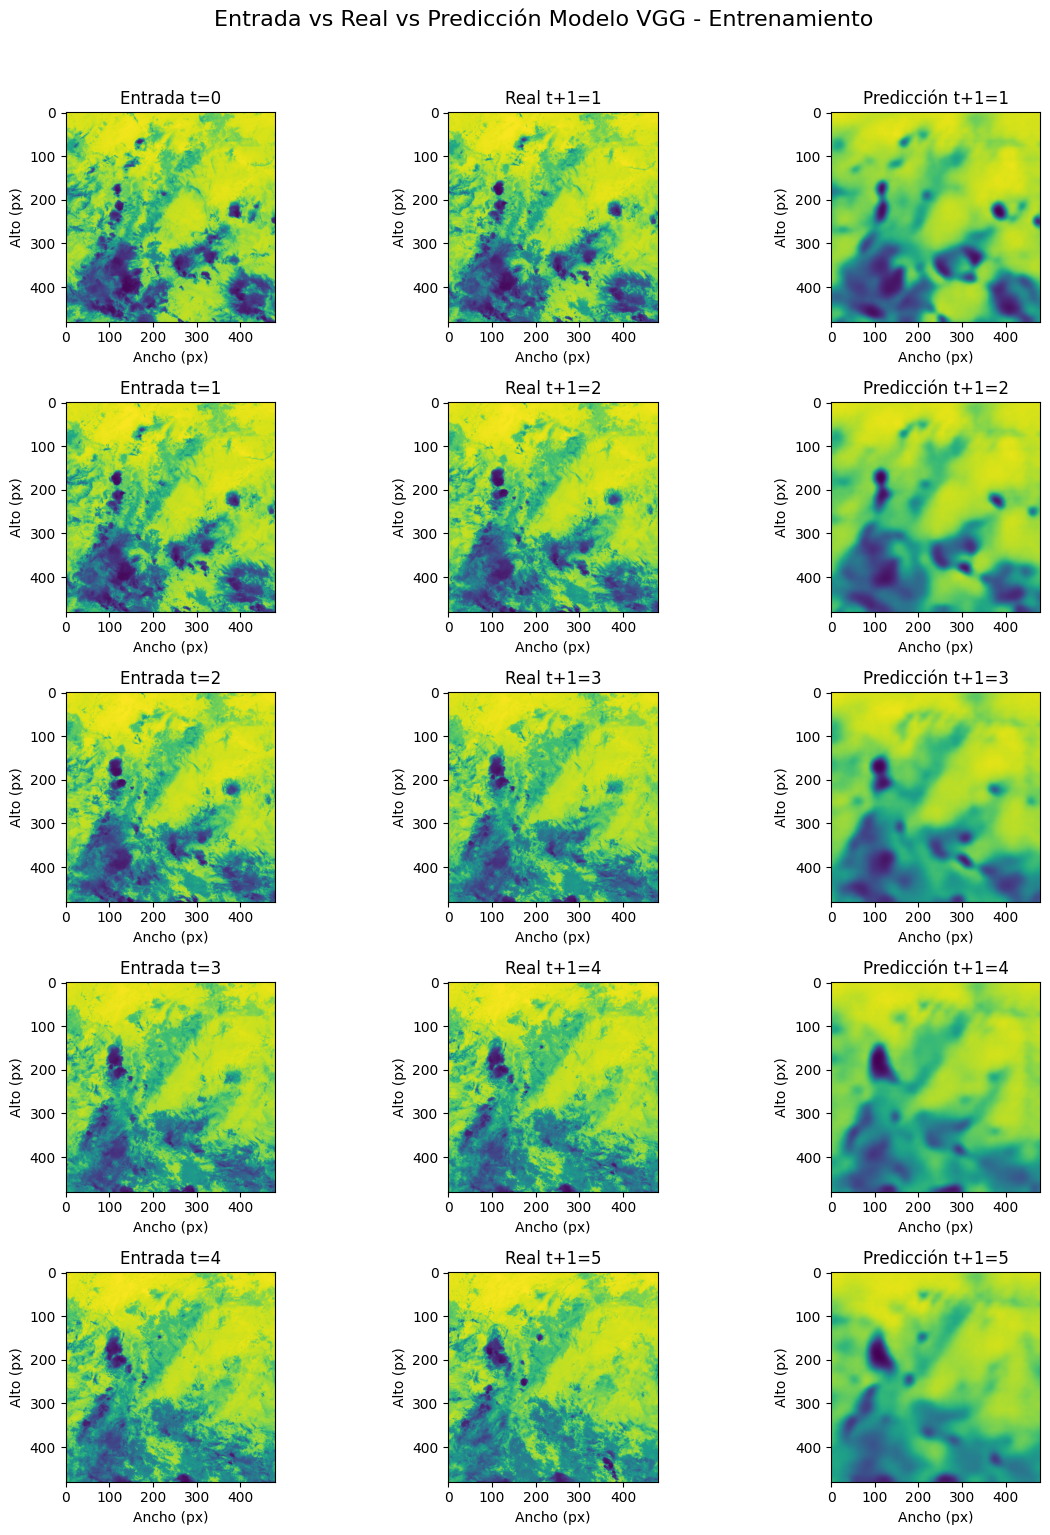

In [9]:
y_pred12 = model_vgg.predict(X_train)  # Genera las predicciones
mostrar_resultados(
    X_train, y_train, y_pred12, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo VGG - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

Prueba:

In [12]:
# Directorio original y reducido para validación
d_mar_2s_red = '/home/jhon/bandas/banda13/nov_dic_2m_red'

# Llamar a la función para redimensionar imágenes

# Cargar imágenes de validación
file_list_test = sorted([f for f in os.listdir(d_mar_2s_red) if f.endswith('.npy')])
print(f"Procesando {len(file_list_test)} imágenes para validación")

images_test = [np.load(os.path.join(d_mar_2s_red, f)) for f in file_list_test]

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images_test])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images_test = [(img - global_min) / (global_max - global_min + 1e-8) for img in images_test]
images_test = [np.clip(img, 0, 1) for img in images_test]


X_test = np.array(images_test[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_test = np.array(images_test[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_test.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_test.shape}")  # Imprime la forma del array de salida


Procesando 1447 imágenes para validación
Forma de X: (1446, 480, 480, 1)
Forma de y: (1446, 480, 480, 1)


Metricas de testeo

In [13]:
# Obtener las métricas del modelo en el conjunto de test
loss, rmse, mape = model_vgg.evaluate(X_test, y_test, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 351ms/step - loss: 0.0202 - mean_absolute_percentage_error: 144.6992 - root_mean_squared_error: 0.1421
Pérdida (MSE): 0.0202
RMSE: 0.1421
MAPE: 144.6992


Visualización de imagenes con conjunto de prueba

46/46 ━━━━━━━━━━━━━━━━━━━━ 13s 273ms/step


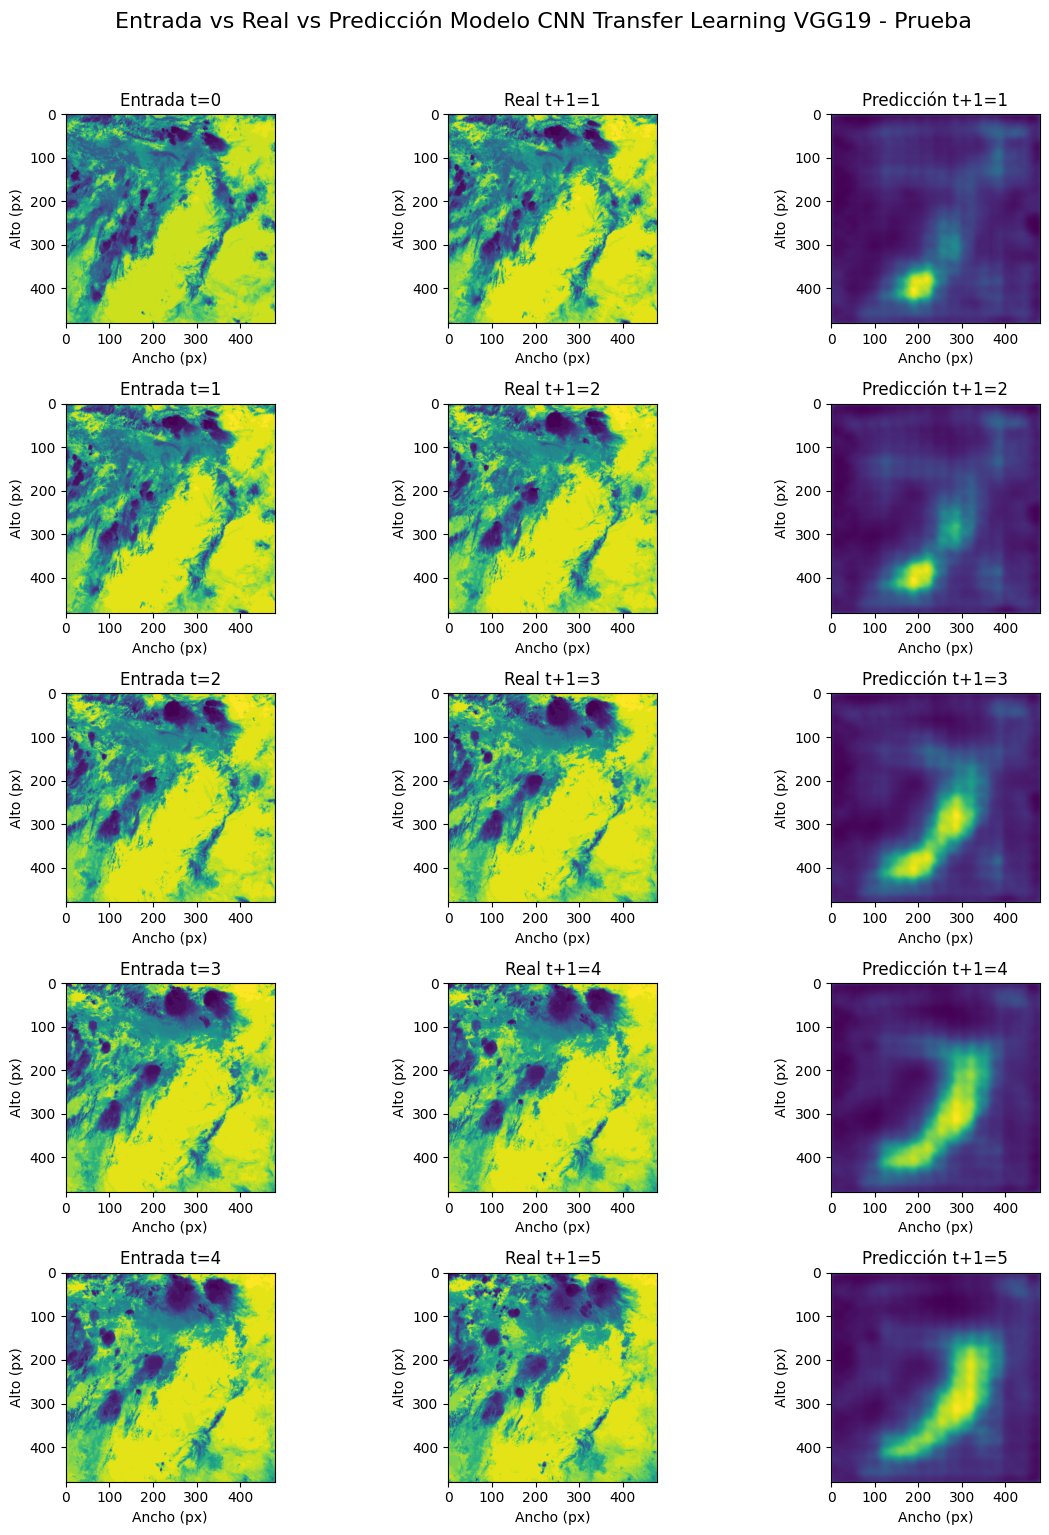

In [14]:
y_pred12_test = model_vgg.predict(X_test)  # Genera las predicciones
mostrar_resultados(
    X_test, y_test, y_pred12_test, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo CNN Transfer Learning VGG19 - Prueba",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

FASE 2

RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 0.0050, RMSE final: 0.0710, MAPE final: 15.8637
Validación    - Loss final: 0.0082, RMSE final: 0.0906, MAPE final: 21.7834


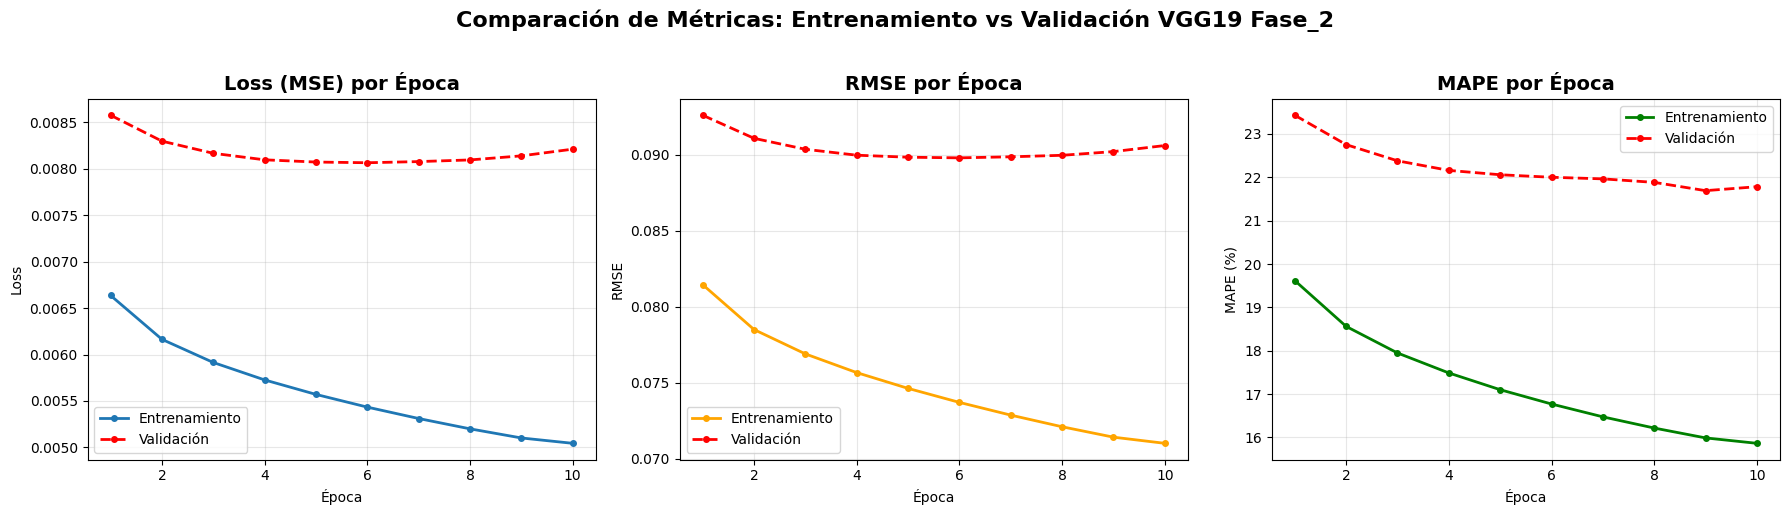

In [15]:
import matplotlib.pyplot as plt

# Extraer métricas del historial (entrenamiento y validación)
loss = history_phase2.history['loss']
val_loss = history_phase2.history['val_loss']

rmse = history_phase2.history['root_mean_squared_error']
val_rmse = history_phase2.history['val_root_mean_squared_error']
mape = history_phase2.history['mean_absolute_percentage_error']
val_mape = history_phase2.history['val_mean_absolute_percentage_error']

epochs = range(1, len(loss) + 1)

# Mostrar resumen final
print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss final: {val_loss[-1]:.4f}, RMSE final: {val_rmse[-1]:.4f}, MAPE final: {val_mape[-1]:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_rmse, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_mape, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación VGG19 Fase_2',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()